# Descriptive Analysis

다음 DataFrame들을 생성하고, 필요에 따라 시각화를 수행함.

* `annual_temperature`: `year`를 기준으로 한 `tavg`, `tmin`, `tmax`의 연평균 데이터 (단, 1907년, 1950~1953년, 2026년은 `NaN` 처리).
* `seasonal_temperature`: `year` 대신 `season_year`를 기준으로 한 `tavg`의 여름(6~8월) 및 겨울(12월~이듬해 2월) 평균 데이터. (단, 2026년 여름은 데이터에서 제외하므로 2026년의 여름과 겨울 데이터는 포함되지 않음. 1907년과 1950~1953년은 기존 결측치가 이미 계절별로 잘 구분되어 있으므로 제공된 데이터를 그대로 사용).
* `annual_over_35`: `year`를 기준으로 `tmax`가 35도 이상인 연간 일수. `dataset_processed.csv` 데이터를 그대로 사용하며, 1907년, 1950~1953년, 2026년 데이터도 있는 그대로 포함.
* `monthly_ratio`: 각 월별 `summer_like`와 `winter_like` 일수의 합을 해당 월의 전체 일수로 나눈 평균값. 2026년 8월 데이터만 제외하고, 1907년, 1950~1953년, 2026년 데이터는 있는 그대로 사용.

In [10]:
# Load processed data
%matplotlib inline              
# %matplotlib widget

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

INPUT_PATH = "../data/processed/dataset_processed.csv"

df2 = pd.read_csv(INPUT_PATH)
df2["date"] = pd.to_datetime(df2["date"])

print(df2.head())
print(df2.info())

        date  tavg  tmin  tmax  year  month  day  day_of_year  season_year  \
0 1907-10-01  13.5   7.9  20.7  1907     10    1          274         1907   
1 1907-10-02  16.2   7.9  22.0  1907     10    2          275         1907   
2 1907-10-03  16.2  13.1  21.3  1907     10    3          276         1907   
3 1907-10-04  16.5  11.2  22.0  1907     10    4          277         1907   
4 1907-10-05  17.6  10.9  25.4  1907     10    5          278         1907   

   season  summer_like  winter_like  warm_day  hot_day  over_35  cold_day  
0  Autumn            0            0         0        0        0         0  
1  Autumn            0            0         0        0        0         0  
2  Autumn            0            0         0        0        0         0  
3  Autumn            0            0         0        0        0         0  
4  Autumn            0            0         1        0        0         0  
<class 'pandas.DataFrame'>
RangeIndex: 42236 entries, 0 to 42235
Data colum

## 1. Annual temperature statistics

Calculate annual average, minimum, and maximum temperature (excl. 1907, 1950-1953, 2026):

In [11]:
# 'year' 사용; 'season_year' 사용x 

annual_temperature = (
    df2.groupby("year")
    .agg(
        avg_temp=("tavg", "mean"),
        avg_min_temp=("tmin", "mean"),
        avg_max_temp=("tmax", "mean")
    ).reset_index()
)

# Mark incomplete years as missing
incomplete_years = [1907, 1950, 1951, 1952, 1953, 2026]

annual_temperature.loc[
    annual_temperature["year"].isin(incomplete_years),
    ["avg_temp", "avg_min_temp", "avg_max_temp"]
] = np.nan

annual_temperature.to_csv("../data/processed/annual_temperature.csv", index=False, encoding="utf-8-sig")

print(annual_temperature.head())

   year   avg_temp  avg_min_temp  avg_max_temp
0  1907        NaN           NaN           NaN
1  1908  10.427322      5.799727     15.771858
2  1909  10.608767      5.832603     16.011507
3  1910  10.412055      5.752603     16.008767
4  1911  10.654795      6.035616     16.001644


In [12]:
print(annual_temperature.tail())

     year   avg_temp  avg_min_temp  avg_max_temp
113  2022  13.296164      9.207143     18.077808
114  2023  14.109041     10.066027     18.800000
115  2024  14.875410     10.975137     19.539891
116  2025  14.150411     10.218904     18.697808
117  2026        NaN           NaN           NaN


Visualize annual average temperature:

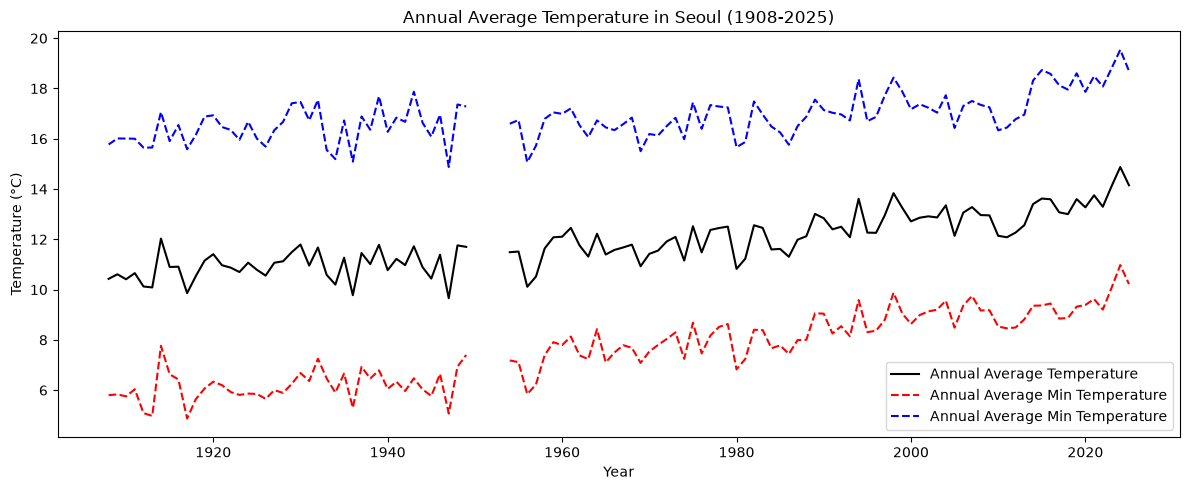

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(annual_temperature["year"], annual_temperature["avg_temp"], 'k-', label="Annual Average Temperature")
plt.plot(annual_temperature["year"], annual_temperature["avg_min_temp"], 'r--', label="Annual Average Min Temperature")
plt.plot(annual_temperature["year"], annual_temperature["avg_max_temp"], 'b--', label="Annual Average Min Temperature")
plt.xlabel("Year")
plt.ylabel("Temperature (°C)")
plt.title("Annual Average Temperature in Seoul (1908-2025)")
plt.legend(loc=4)
plt.tight_layout()
plt.show()

* 서울시 연평균 평균온도, 최저온도, 최고온도는 상승세에 있음. (선형회귀 분석은 후에 할 예정)
* 1907년, 2026년과 1950~1953년은 수개월 동안의 결측치로 인해 제외되었음.

## 2. Summer and winter temperature

Calculate 'summer' (6월~8월) and 'winter' (12월~2월) average temperatures:

In [23]:
# 'season_year' 사용

seasonal_temperature = (
    df2[df2["season"].isin(["Summer", "Winter"])]
    .groupby(["season_year", "season"])["tavg"]
    .mean()
    .reset_index()
)

# 2026년 여름 제외 (데이터가 2026/08/19까지만 있으므로)
seasonal_temperature = seasonal_temperature[
    ~((seasonal_temperature["season"] == "Summer") &
      (seasonal_temperature["season_year"] == 2026))
]

print(seasonal_temperature.head())

   season_year  season       tavg
0         1907  Winter  -3.798901
1         1908  Summer  22.872826
2         1908  Winter  -2.157778
3         1909  Summer  23.510870
4         1909  Winter  -3.020000


In [25]:
# reshape the table

seasonal_temperature_pivot = (
    seasonal_temperature
    .pivot(
        index="season_year",
        columns="season",
        values="tavg"
    ).reset_index()
)

print(seasonal_temperature_pivot.head())

season  season_year     Summer    Winter
0              1907        NaN -3.798901
1              1908  22.872826 -2.157778
2              1909  23.510870 -3.020000
3              1910  22.463043 -3.632222
4              1911  22.961957 -2.287912


In [26]:
print(seasonal_temperature_pivot.tail())

season  season_year     Summer    Winter
112            2021  25.628261 -0.905556
113            2022  25.481522 -0.778889
114            2023  25.784783  1.431868
115            2024  26.865217 -0.221111
116            2025  27.052174  0.027778


Visualize summer vs. winter graph:

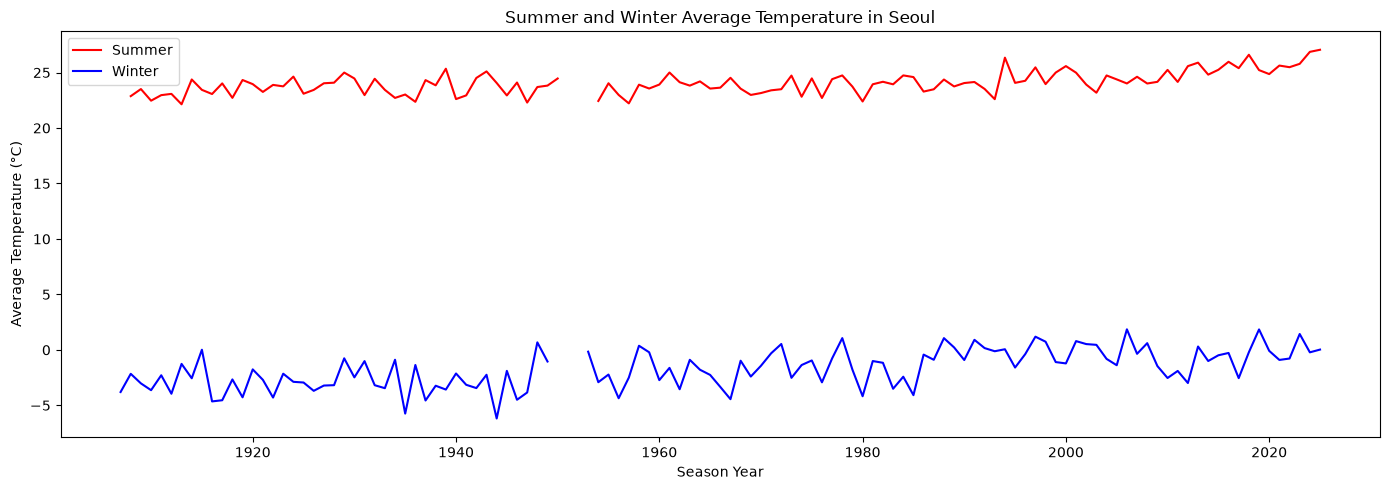

In [27]:
plt.figure(figsize=(14, 5))
plt.plot(seasonal_temperature_pivot["season_year"],
         seasonal_temperature_pivot["Summer"],
         label="Summer", color="red")
plt.plot(seasonal_temperature_pivot["season_year"],
         seasonal_temperature_pivot["Winter"],
         label="Winter", color="blue")
plt.xlabel("Season Year")
plt.ylabel("Average Temperature (°C)")
plt.title("Summer and Winter Average Temperature in Seoul")
plt.legend()
plt.tight_layout()
plt.show()

* 서울시 여름(6월~8월)/겨울(12월~2월) 평균기온은 상승세에 있음.

Rename the column names and save dataset:

In [29]:
seasonal_temperature_pivot = seasonal_temperature_pivot.rename(columns={
    "Summer": "summer_avg_temp",
    "Winter": "winter_avg_temp"
})

seasonal_temperature_pivot.to_csv("../data/processed/seasonal_temperature.csv", index=False, encoding="utf-8-sig")

print(seasonal_temperature_pivot.head())
print(seasonal_temperature_pivot.tail())

season  season_year  summer_avg_temp  winter_avg_temp
0              1907              NaN        -3.798901
1              1908        22.872826        -2.157778
2              1909        23.510870        -3.020000
3              1910        22.463043        -3.632222
4              1911        22.961957        -2.287912
season  season_year  summer_avg_temp  winter_avg_temp
112            2021        25.628261        -0.905556
113            2022        25.481522        -0.778889
114            2023        25.784783         1.431868
115            2024        26.865217        -0.221111
116            2025        27.052174         0.027778


## 3. Annual 35°C+ days

* 최고 기온(`tmax`)이 35°C 이상인 일수. 'over'라고 했지만 35°C를 포함하기로 함.

In [30]:
annual_over_35 = (df2.groupby("year")["over_35"].sum().reset_index(name="days_over_35"))
print(annual_over_35.head())
print(annual_over_35.tail())

   year  days_over_35
0  1907             0
1  1908             0
2  1909             1
3  1910             0
4  1911             0
     year  days_over_35
113  2022             2
114  2023             1
115  2024             6
116  2025            13
117  2026             7


In [31]:
annual_over_35.to_csv("../data/processed/annual_over_35.csv", index=False, encoding="utf-8-sig")

Visualize it using a bar graph:

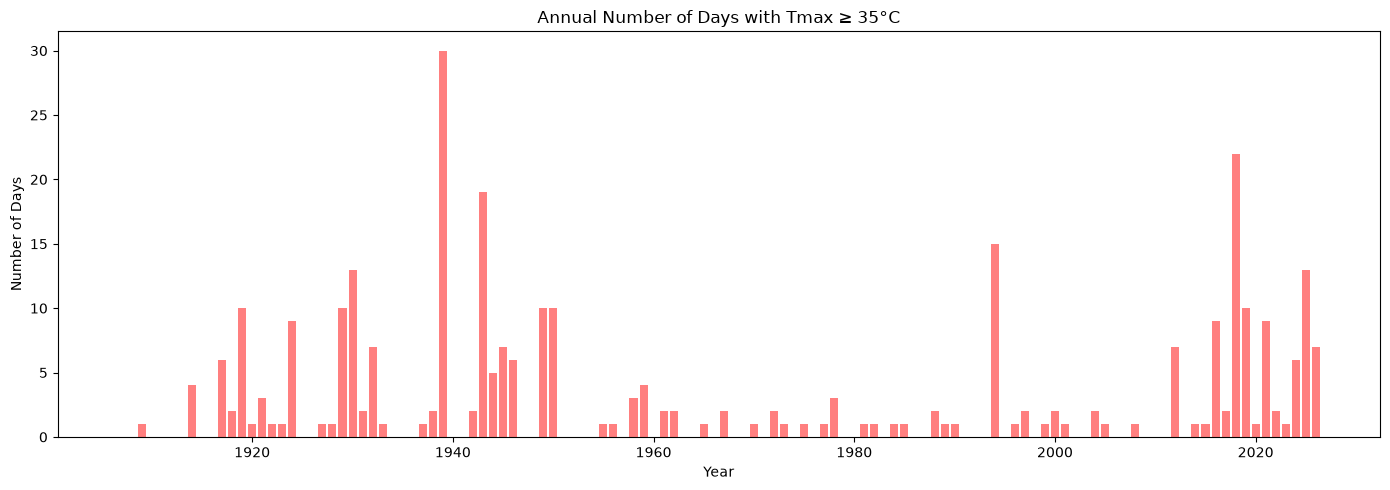

In [33]:
plt.figure(figsize=(14, 5))
plt.bar(annual_over_35["year"], annual_over_35["days_over_35"], color="red", alpha=0.5)
plt.xlabel("Year")
plt.ylabel("Number of Days")
plt.title("Annual Number of Days with Tmax ≥ 35°C")
plt.tight_layout()
plt.show()

In [32]:
annual_over_35_sorted = annual_over_35.sort_values(by="days_over_35", ascending=False)
print(annual_over_35_sorted.head(10))

     year  days_over_35
32   1939            30
109  2018            22
36   1943            19
85   1994            15
23   1930            13
116  2025            13
43   1950            10
22   1929            10
12   1919            10
42   1949            10


* 지난 100여 년간 35°C 이상인 날의 발생 일수는 1939년에 가장 많았으며(30일), 그다음으로 2018년(22일)과 1943년(19일)이 높은 수준을 기록했다. 특히 1910~1950년 사이에는 35°C 이상인 날이 여러 차례 집중적으로 나타난 반면, 1950~1990년에는 대부분 연간 5일 미만으로 나타났다. 이후 1994년에는 약 15일로 크게 증가했으며, 2012년 이후에는 35°C 이상인 날이 전반적으로 증가하는 경향이 나타난다. 2020년대에는 35°C 이상인 날이 대체로 연간 5~15일 수준으로 나타나고 있다.

## 4. Monthly summer-like / winter-like ratios

This is to answer to the question about seasonal expansion. Instead of simply counting the number of summer-like days, calculated the proportion of days in each month that meet the temperature criterion.

즉, 5월의 31일 중 10일이 summer_like=1 이라면 → 평균 = 10/31 = 0.3226. "그 달에 여름 날이 차지하는 비율은 32.26%".

In [35]:
# 2026년 8월만 빼고 진행

monthly_ratio = (
    df2.groupby(["year", "month"])
      .agg(
          summer_like_ratio=("summer_like", "mean"),
          winter_like_ratio=("winter_like", "mean")
      )
      .reset_index()
      .query("not (year == 2026 and month == 8)")
)

print(monthly_ratio.head())
print(monthly_ratio.tail())

   year  month  summer_like_ratio  winter_like_ratio
0  1907     10                0.0           0.000000
1  1907     11                0.0           0.400000
2  1907     12                0.0           1.000000
3  1908      1                0.0           1.000000
4  1908      2                0.0           0.965517
      year  month  summer_like_ratio  winter_like_ratio
1382  2026      3           0.000000           0.225806
1383  2026      4           0.066667           0.000000
1384  2026      5           0.483871           0.000000
1385  2026      6           1.000000           0.000000
1386  2026      7           1.000000           0.000000


In [36]:
monthly_ratio.to_csv("../data/processed/monthly_ratio.csv", index=False, encoding="utf-8-sig")

본 분석은 한국의 계절이 전통적인 범위(여름 6~8월, 겨울 12~2월)를 넘어 여름과 겨울 중심으로 양극화되는 경향을 확인하고자 한다. 특히 겨울보다는 여름의 확장성에 중점을 두고 분석을 진행할 것이다.
* 여름 확장: May → June → July → August → September
* 겨울 확장: November → December → January → February → March

## 5. Descriptive statistics

In [37]:
print("\n=== Annual Temperature ===")
print(annual_temperature.describe())

print("\n=== Annual 35°C+ Days ===")
print(annual_over_35["days_over_35"].describe())

print("\n=== Summer/Winter Monthly Ratio ===")
print(monthly_ratio[["summer_like_ratio", "winter_like_ratio"]].describe())


=== Annual Temperature ===
              year    avg_temp  avg_min_temp  avg_max_temp
count   118.000000  114.000000    114.000000    114.000000
mean   1966.754237   11.854737      7.574985     16.845528
std      35.025250    1.076659      1.387094      0.886525
min    1907.000000    9.655616      4.872329     14.878082
25%    1936.250000   11.027123      6.343836     16.291350
50%    1967.500000   11.740137      7.602921     16.784413
75%    1996.750000   12.548973      8.631987     17.345656
max    2026.000000   14.875410     10.975137     19.539891

=== Annual 35°C+ Days ===
count    118.000000
mean       2.669492
std        4.789688
min        0.000000
25%        0.000000
50%        1.000000
75%        2.000000
max       30.000000
Name: days_over_35, dtype: float64

=== Summer/Winter Monthly Ratio ===
       summer_like_ratio  winter_like_ratio
count        1387.000000        1387.000000
mean            0.297838           0.311167
std             0.404671           0.402614
min   

## Files saved

* `data/processed/annual_temperature.csv`
* `data/processed/seasonal_temperature.csv`
* `data/processed/annual_over_35.csv`
* `data/processed/monthly_ratio.csv`